In [2]:
# DATA 

In [3]:
import pandas as pd
import numpy as np

In [4]:
# Load dataset hasil notebook sebelumnya
df = pd.read_csv('clean_dataset_rica_manado_final.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal')

# --- TAMBAHAN FITUR REKOMENDASI ---
# 1. Rolling Mean (Smoothing tren 1 & 2 minggu)
df['Rolling_Mean_7'] = df['Harga'].rolling(window=7).mean()
df['Rolling_Mean_14'] = df['Harga'].rolling(window=14).mean()

# 2. Volatilitas (Standard Deviasi mingguan)
df['Harga_Std_7'] = df['Harga'].rolling(window=7).std()

# 3. Lag Bulanan (Siklus tanam/suplai)
df['Harga_Lag_30'] = df['Harga'].shift(30)

# Hapus baris kosong akibat rolling/lag baru
df = df.dropna().reset_index(drop=True)

print(f"Total baris final: {len(df)}")

Total baris final: 2244


In [7]:
feature_cols = [
    # Fitur cuaca (nama asli dari BMKG)
    'RR',      # Curah Hujan
    'TAVG',    # Suhu rata-rata
    'RH_AVG',  # Kelembapan rata-rata
    # Fitur lag
    'Harga_Lag_1', 'Harga_Lag_7', 'Harga_Lag_30',
    # Fitur rolling
    'Rolling_Mean_7', 'Rolling_Mean_14', 'Harga_Std_7',
    # Fitur waktu & kalender
    'Bulan', 'Tahun', 'Is_Hari_Raya'
]

print(df[feature_cols].isnull().sum())
print(f"Shape: {df.shape}")

RR                 0
TAVG               0
RH_AVG             0
Harga_Lag_1        0
Harga_Lag_7        0
Harga_Lag_30       0
Rolling_Mean_7     0
Rolling_Mean_14    0
Harga_Std_7        0
Bulan              0
Tahun              0
Is_Hari_Raya       0
dtype: int64
Shape: (2244, 15)


In [8]:
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print(f"Train: {len(train)} baris | {train['Tanggal'].min().date()} s/d {train['Tanggal'].max().date()}")
print(f"Test:  {len(test)} baris  | {test['Tanggal'].min().date()} s/d {test['Tanggal'].max().date()}")

Train: 1795 baris | 2020-02-08 s/d 2025-01-06
Test:  449 baris  | 2025-01-07 s/d 2026-03-31


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler_features = MinMaxScaler()

train[feature_cols] = scaler_features.fit_transform(train[feature_cols])
test[feature_cols]  = scaler_features.transform(test[feature_cols])

In [11]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 330.3 kB/s eta 0:05:08
   ---------------------------------------- 0.1/101.7 MB 365.7 kB/s eta 0:04:38
   ---------------------------------------- 0.1/101.7 MB 602.4 kB/s eta 0:02:49
   ---------------------------------------- 0.2/101.7 MB 787.7 kB/s eta 0:02:09
   ---------------------------------------- 0.3/101.7 MB 947.5 kB/s eta 0:01:48
   ---------------------------------------- 0.3/101.7 MB 999.0 kB/s eta 0:01:42
   ---------------------------------------- 0.4/101.7 MB 1.1 MB/s eta 0:01:32
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:29
   ---------------------------------------- 0.6/101.7 MB 1.2 MB/s eta 0:01:21
   ---------------------------------------- 0.7/101.7 MB 1.3 MB/s eta 0:0

In [12]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error

X_train, y_train = train[feature_cols], train['Harga']
X_test,  y_test  = test[feature_cols],  test['Harga']

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"\nRMSE : Rp {rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")

[0]	validation_0-rmse:19.70880
[50]	validation_0-rmse:6.30964
[100]	validation_0-rmse:6.52842
[150]	validation_0-rmse:6.63544
[200]	validation_0-rmse:6.76784
[250]	validation_0-rmse:6.73164
[299]	validation_0-rmse:6.74376

RMSE : Rp 7
MAPE : 8.53%


In [13]:
print(f"Rata-rata harga aktual (test): {y_test.mean():,.0f}")
print(f"Rata-rata prediksi (test):     {preds.mean():,.0f}")
print(f"Sample harga aktual: {y_test.values[:5]}")

Rata-rata harga aktual (test): 59
Rata-rata prediksi (test):     61
Sample harga aktual: [68.   60.   75.25 70.25 70.25]


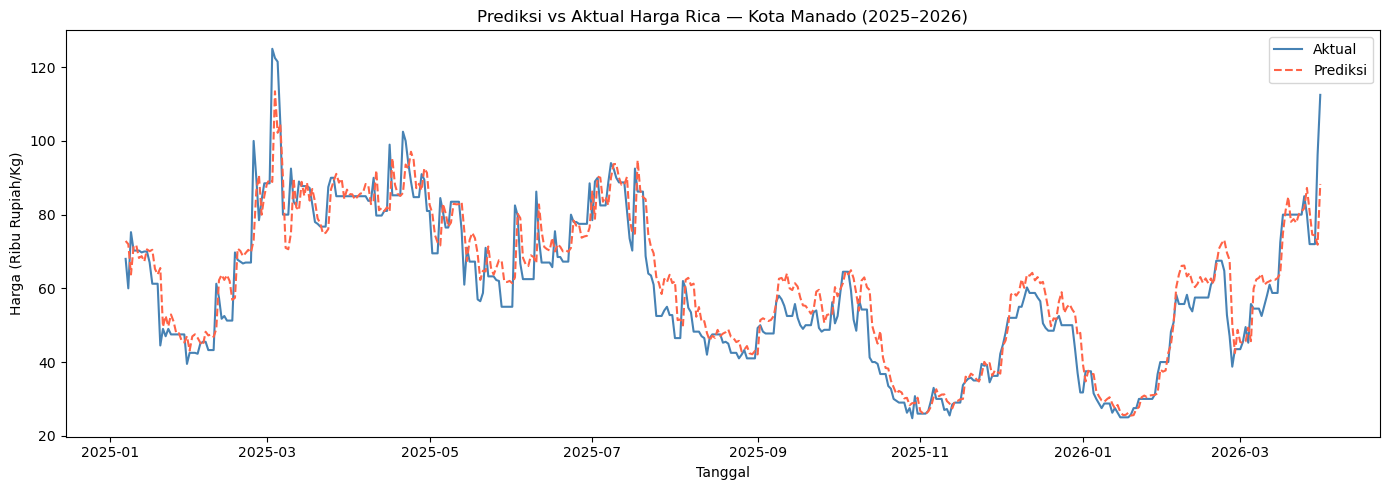


RMSE : Rp 6,744
MAPE : 8.53%


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

hasil = pd.DataFrame({
    'Tanggal': test['Tanggal'].values,
    'Aktual':  y_test.values,
    'Prediksi': preds
})

plt.figure(figsize=(14, 5))
plt.plot(hasil['Tanggal'], hasil['Aktual'],  label='Aktual',   color='steelblue', linewidth=1.5)
plt.plot(hasil['Tanggal'], hasil['Prediksi'], label='Prediksi', color='tomato', linewidth=1.5, linestyle='--')
plt.title('Prediksi vs Aktual Harga Rica — Kota Manado (2025–2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Ribu Rupiah/Kg)')
plt.legend()
plt.tight_layout()
plt.savefig('prediksi_vs_aktual.png', dpi=150)
plt.show()

print(f"\nRMSE : Rp {rmse*1000:,.0f}")
print(f"MAPE : {mape:.2f}%")

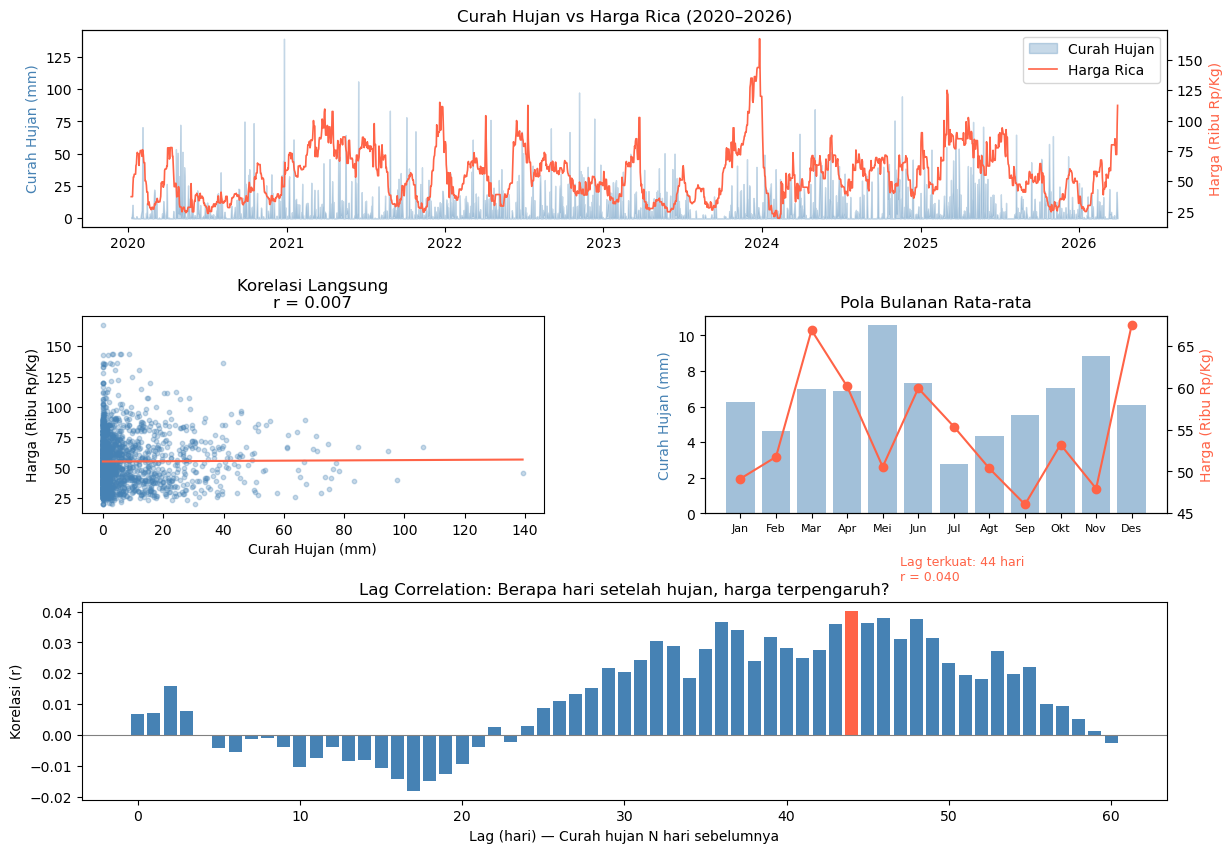

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Time series dual axis ---
ax1 = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.fill_between(df_ori['Tanggal'], df_ori['RR'], alpha=0.3, color='steelblue', label='Curah Hujan')
ax1b.plot(df_ori['Tanggal'], df_ori['Harga'], color='tomato', linewidth=1.2, label='Harga Rica')
ax1.set_ylabel('Curah Hujan (mm)', color='steelblue')
ax1b.set_ylabel('Harga (Ribu Rp/Kg)', color='tomato')
ax1.set_title('Curah Hujan vs Harga Rica (2020–2026)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- Plot 2: Scatter korelasi ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df_ori['RR'], df_ori['Harga'], alpha=0.3, s=10, color='steelblue')
z = np.polyfit(df_ori['RR'], df_ori['Harga'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_ori['RR'].min(), df_ori['RR'].max(), 100)
ax2.plot(x_line, p(x_line), color='tomato', linewidth=1.5)
corr = df_ori['RR'].corr(df_ori['Harga'])
ax2.set_xlabel('Curah Hujan (mm)')
ax2.set_ylabel('Harga (Ribu Rp/Kg)')
ax2.set_title(f'Korelasi Langsung\nr = {corr:.3f}')

# --- Plot 3: Rata-rata bulanan ---
ax3 = fig.add_subplot(gs[1, 1])
bulanan = df_ori.groupby('Bulan').agg({'RR': 'mean', 'Harga': 'mean'}).reset_index()
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']
x = np.arange(12)
ax3b = ax3.twinx()
ax3.bar(x, bulanan['RR'], color='steelblue', alpha=0.5, label='Curah Hujan')
ax3b.plot(x, bulanan['Harga'], color='tomato', marker='o', linewidth=1.5, label='Harga')
ax3.set_xticks(x)
ax3.set_xticklabels(nama_bulan, fontsize=8)
ax3.set_ylabel('Curah Hujan (mm)', color='steelblue')
ax3b.set_ylabel('Harga (Ribu Rp/Kg)', color='tomato')
ax3.set_title('Pola Bulanan Rata-rata')

# --- Plot 4: Lag correlation ---
ax4 = fig.add_subplot(gs[2, :])
lags = range(0, 61)
lag_corrs = [df_ori['Harga'].corr(df_ori['RR'].shift(lag)) for lag in lags]
colors = ['tomato' if c == max(lag_corrs) else 'steelblue' for c in lag_corrs]
ax4.bar(lags, lag_corrs, color=colors)
ax4.axhline(0, color='gray', linewidth=0.8)
ax4.set_xlabel('Lag (hari) — Curah hujan N hari sebelumnya')
ax4.set_ylabel('Korelasi (r)')
ax4.set_title('Lag Correlation: Berapa hari setelah hujan, harga terpengaruh?')
best_lag = lags[lag_corrs.index(max(lag_corrs))]
ax4.annotate(f'Lag terkuat: {best_lag} hari\nr = {max(lag_corrs):.3f}',
             xy=(best_lag, max(lag_corrs)),
             xytext=(best_lag+3, max(lag_corrs)+0.01),
             fontsize=9, color='tomato')

plt.savefig('analisis_curah_hujan_harga.png', dpi=150, bbox_inches='tight')
plt.show()